In [2]:
from IPython.display import Image

## 3) 사람 자세 인식

 - 사람은 가장 중요한 분석 대상
 - 전신 자세, 손 자세, 얼굴 표정 등 

## Google의 Mediapipe
- On-device (모바일 등)에 적용 가능한 Google의 핵심 AI 라이브러리      
- 2012년에 Google 내부 프로젝으로 시작, 2019년에 공개 (CVPR)
- Vison, Text, Audio 분야를 모두 제공
- Vision 분야 대표 기능
    - 핸드 트래킹 (Hand Landmark Detection): 손가락 마디마디 고유 랜드마크(21개)를 추적하여 손 모양이나 제스처 인식.
    - 페이스 메쉬 (Face Landmark Detection): 얼굴의 수백 개 밀밀한 포인트(468개 이상)를 실시간으로 추적하여 증강현실(AR) 필터나 시선 추적에 활용.
    - 포즈 추정 (Pose Landmark Detection): 신체 주요 관절 포인트를 추적하여 운동 자세 분석이나 행동 인식에 활용.
    - 홀리스틱 추적 (Holistic Landmarks): 얼굴, 손, 포즈를 동시에 실시간으로 추적하는 통합 파이프라인.
    - 객체 검출 및 세그멘테이션 (Object Detection & Segmentation): 실시간 사물 인식 및 배경 분리(예: 화상회의 배경 대치).


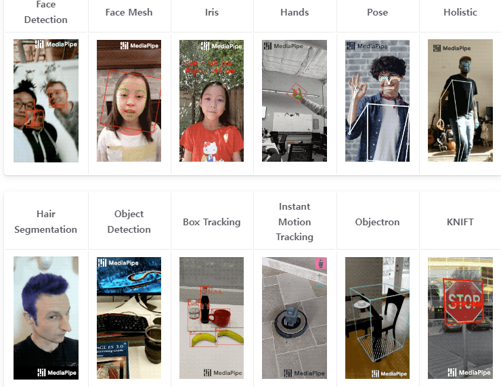

In [4]:
Image("mediapipe.png", width=720)

In [7]:
import yt_dlp
def get_youtube_streamlink(youtube_url):

    # 1. yt-dlp를 이용하여 유튜브에서 실제 비디오 스트림 URL 추출
    ydl_opts = {
        # 720p 이하의 mp4 포맷 중 오디오가 포함된 비디오 선택 (RTX 4090이라도 실시간 스트리밍 대역폭 고려)
        'format': 'best[ext=mp4][height<=720]/best[height<=720]',
        'quiet': True,
        'cookiesfrombrowser': ('chrome',),  
    }

    print("유튜브 비디오 스트림 주소를 추출 중입니다...")
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(youtube_url, download=False)
        # OpenCV가 직접 읽을 수 있는 실시간 재생용 원격 URL 가공
        video_stream_url = info['url']
        print(video_stream_url)
        return video_stream_url    

## MEDIAPIPE DEMO
1. Full body pose
2. Face landmarks
3. Hand pose

In [34]:
# Be careful for version issues!!
#!pip install numpy==1.26.4
!pip install mediapipe opencv-python "numpy<2"


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## 1) Body Pose
- human pose definition in Openpose
    - OpenPose: 25 points, Mediapipe (BlazePose): 33 points
- SMPL 3D human mesh model (popular model in research)


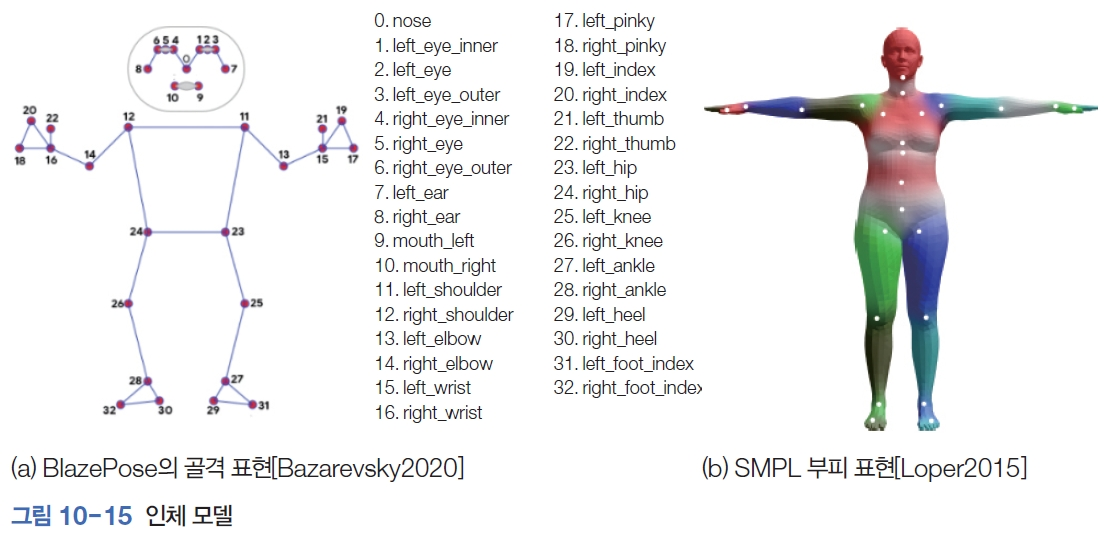

In [21]:
Image("그림 10-15.jpg", width=720)

###  포즈 추정 접근 방식 비교: 하향식(Top-down) vs. 상향식(Bottom-up)

| 비교 항목 | 하향식 기법 (Top-down Approach) | 상향식 기법 (Bottom-up Approach) |
| :--- | :--- | :--- |
| **대표적인 모델** | **MediaPipe**, AlphaPose, Mask R-CNN | **OpenPose**, PAF 기반 모델들 |
| **핵심 매커니즘** | 화면에서 **사람(객체)을 먼저 검출**한 뒤, 각 사람의 바운딩 박스 영역 내부에서 관절 점들을 찾아냅니다. | 화면 내의 **모든 관절 점들을 먼저 전부 검출**한 뒤, 이 점들을 연결하고 그룹화하여 개별 인체의 골격으로 조립합니다. |
| **랜드마크 상관관계** | 신체 구조적 제약 조건(골격 토폴로지)을 활용하여, 연결된 관절을 따라 탐색 범위를 순차적으로 좁혀나갑니다. | 인체 부위의 방향성과 두께 정보를 담은 2차원 벡터 지도인 **PAF(Part Affinity Fields)**를 사용하여 유효한 연결을 필터링하고 강화합니다. |
| **확장성 (대규모 군중)** | **사람 수가 많아질수록 속도가 느려집니다.**<br>(연산량이 검출된 사람의 수에 비례하여 선형적으로 증가합니다.) | **인원 수와 무관하게 처리 속도가 일정합니다.**<br>(사람 수에 종속되지 않고 화면 전체를 한 번에 통과시켜 연산합니다.) |
| **주요 장점** | 가려짐이 없는 단일 피사체에 대해 정확도가 매우 높으며, 에지 단말(모바일/임베디드)에서 단인 인간을 추적할 때 압도적으로 가볍고 빠릅니다. | 인파가 몰려 있는 복잡한 화면에 강력하며, 여러 사람이 서로 겹치거나 교차하는 상황을 자연스럽게 처리할 수 있습니다. |
| **주요 단점** | 첫 단계인 사람 검출기(Person-detector)가 사람을 놓치면, 해당 인물의 내부 관절은 아예 추정할 수 없습니다. | 검출된 수많은 점들을 올바른 사람에게 매칭하는 조합 최적화(그래프 파싱) 단계에서 하드웨어 자원(GPU 등) 소모가 매우 큽니다. |

---

💡 **비유:**
* **하향식 (MediaPipe):** *"화면에서 먼저 사람 인형 판넬을 찾아서 고정한 뒤, 그 판넬 위에 관절 핀을 꽂아나가는 방식"*
* **상향식 (OpenPose):** *"바닥에 수많은 관절 부품들을 먼저 다 뿌려놓고, 자석(방향 벡터)의 끌어당기는 힘을 이용해 각 부품들을 알아서 척척 조립되게 만드는 방식"*

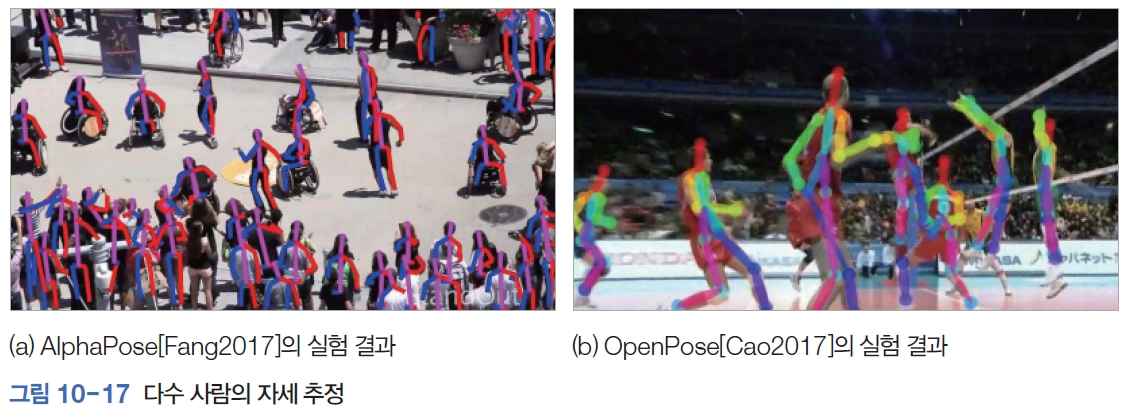

In [23]:
Image("그림 10-17.jpg", width=720)

#### Peformance (accuracy)

- In range of "a certian" distance of ratio of link/bone from the GT joint postion 

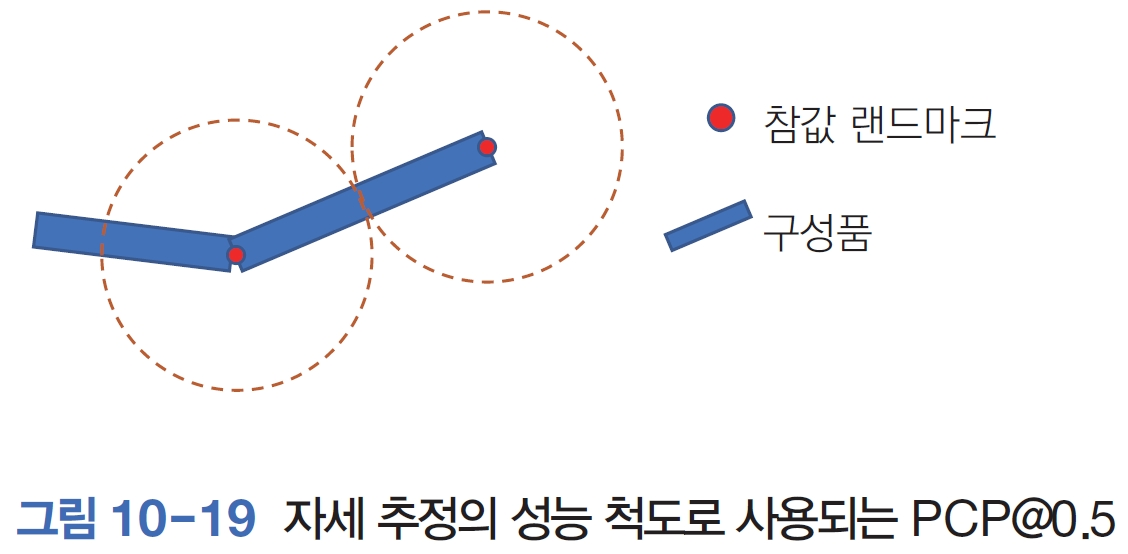

In [3]:
Image("그림 10-19.jpg", width=480)

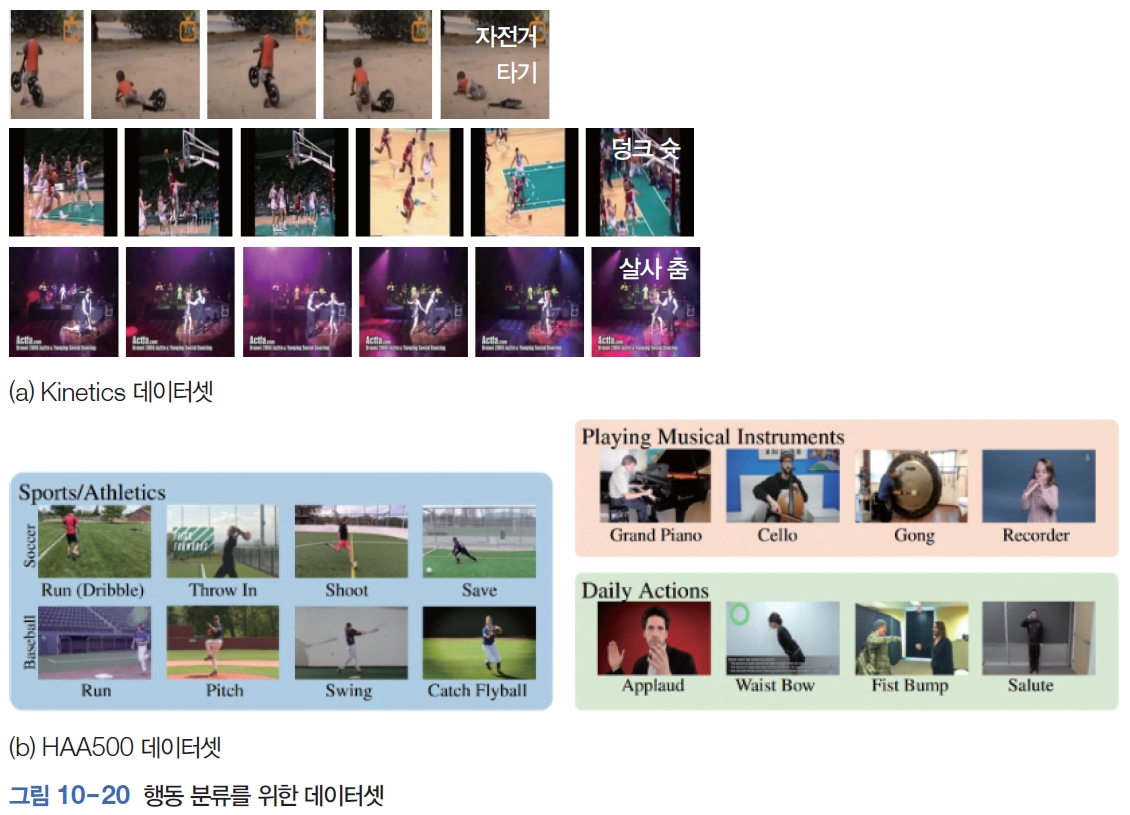

In [27]:
Image("그림 10-20.jpg", width=720)

- 모델 파일 다운로드 (put the same directory of script)

  https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task

In [9]:
import cv2
import mediapipe as mp
import os
import sys

# 1. 사용할 MP4 비디오 파일 경로 지정
#video_path = get_youtube_streamlink("https://youtube.com/shorts/kz9bNgPn0Wo?si=CIZh9WhUiVbycBQC")
cap = cv2.VideoCapture("body.mp4")

# 2. Pose Landmarker 설정 초기화
BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path='pose_landmarker_full.task'),
    running_mode=VisionRunningMode.VIDEO  # 비디오 스트림 모드 유지
)

print("MediaPipe 모델 로드 중...")

with PoseLandmarker.create_from_options(options) as landmarker:
    print("비디오 분석 및 재생을 시작합니다. 종료하려면 'q'를 누르세요.")
    
    while cap.isOpened():
        ret, frame = cap.read()
        
        # 비디오가 끝나면 자동 종료
        if not ret:
            print("비디오 영상 재생이 완료되었습니다.")
            break

        # [핵심] MP4 파일 자체의 현재 프레임 시간 위치(밀리초)를 추출합니다.
        # 정수형(int)으로 변환하여 MediaPipe에 전달해야 에러가 나지 않습니다.
        frame_timestamp_ms = int(cap.get(cv2.CAP_PROP_POS_MSEC))
        
        # OpenCV(BGR) -> MediaPipe(RGB) 변환
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

        # 동영상 프레임 고유 타임스탬프를 포함하여 추론 수행
        result = landmarker.detect_for_video(mp_image, frame_timestamp_ms)

        # 관절 포인트 시각화
        if result.pose_landmarks:
            h, w, _ = frame.shape
            for pose_landmarks in result.pose_landmarks:
                for idx, landmark in enumerate(pose_landmarks):
                    # 가시성이 높은 주요 랜드마크만 시각화
                    if landmark.visibility > 0.5:
                        cx, cy = int(landmark.x * w), int(landmark.y * h)
                        # 관절 위치에 빨간색 원 그리기
                        cv2.circle(frame, (cx, cy), 5, (0, 0, 255), -1)

        # 화면 출력
        cv2.imshow('Pose MP4 Video Tracking', frame)

        # 고해상도 비디오의 경우 연산 속도 확보 및 프레임 제어를 위해 waitKey 조절
        # 'q' 키를 누르면 중간 종료
        if cv2.waitKey(30) & 0xFF == ord('q'):
            print("사용자에 의해 종료되었습니다.")
            break

# 자원 해제
cap.release()
cv2.destroyAllWindows()
for i in range(5): cv2.waitKey(1) # 주피터 노트북 창 닫힘 버그 방지용 데드락 해제
print("자원 해제 완료.")

MediaPipe 모델 로드 중...
비디오 분석 및 재생을 시작합니다. 종료하려면 'q'를 누르세요.


I0000 00:00:1779593869.954105  137960 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1779593869.982248  137978 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 535.309.01), renderer: NVIDIA GeForce RTX 4090/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779593870.027118  137968 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779593870.050458  137971 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779593870.103432  137976 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


사용자에 의해 종료되었습니다.
자원 해제 완료.


### Face Landmarks

#### Mediapiep 얼굴 랜드마크 검출 

- SSD(한 단계 물체 검출 모델)을 얼굴 검출에 적합하게 개조하여 사용 (고속)
- 입력 영상을 16*16, 8*8까지 줄인 맵을 만드는데, 매 화소에 컨볼루션을 적용하여 2~6개의 박스를 예측함
- 비최대 억제(신뢰도가 최대인 박스 선택) 대신, 여러 박스의 가중 평균을 취함
- 얼굴 박스뿐 아니라 6개의 랜드마크(눈 중심, 귀 구슬점, 입 중심, 코끝)까지 추출 

### 얼굴 그물망 
- 468개의 랜드마크 검출
- 첫 프레임에서 BlazeFace로 얼굴 검출. 이후에는 추적만으로 처리 시간을 획기적 단축
- 신뢰도가 임곗값보다 낮으면 BlazeFace를 다시 적용하여 새로 얼굴 검출

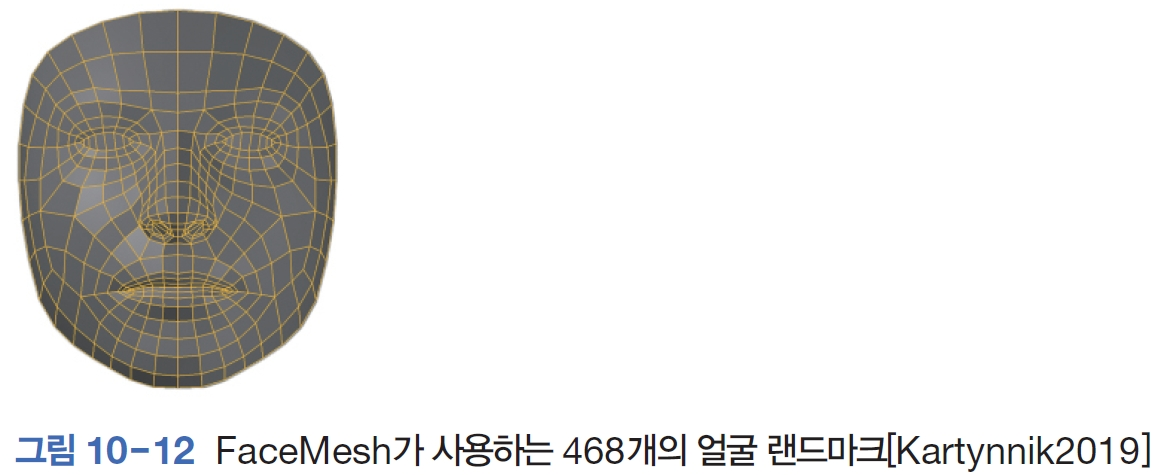

In [18]:
Image("그림 10-12.jpg", width=720)

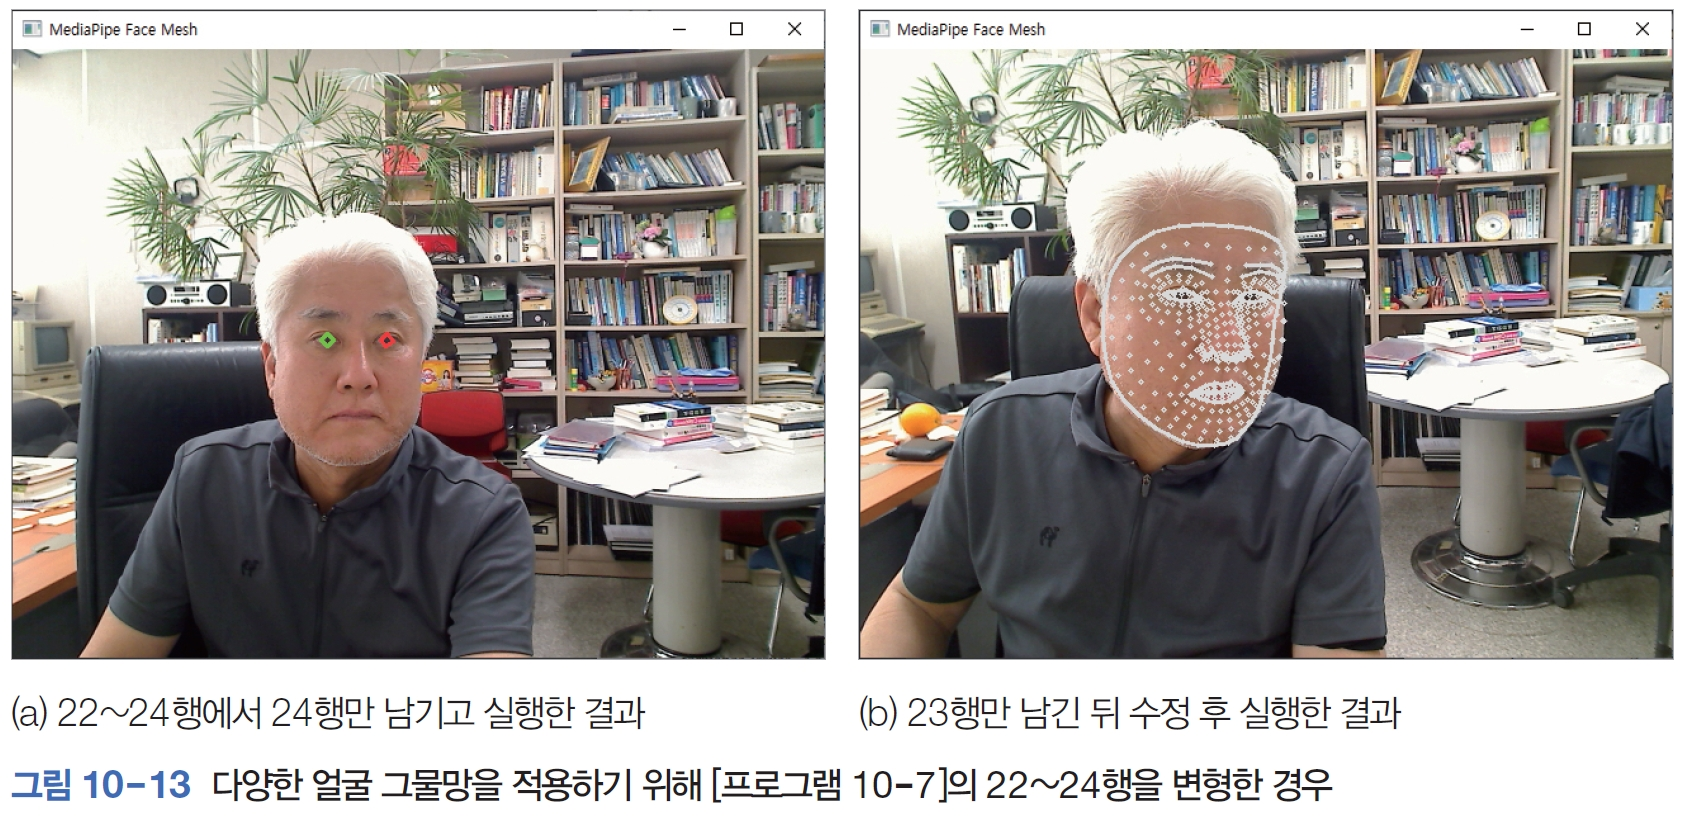

In [13]:
Image("그림 10-13.jpg", width=720)

- face model file link : https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

In [10]:
import cv2
import mediapipe as mp

# 1. 테스트할 유튜브 영상 링크
#stream_link = get_youtube_streamlink("https://www.youtube.com/shorts/xTa3RF1DQ_c")  
cap = cv2.VideoCapture("face.mp4")

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path='face_landmarker.task'),
    running_mode=VisionRunningMode.VIDEO,
    output_face_blendshapes=False, 
    output_facial_transformation_matrixes=False
)

with FaceLandmarker.create_from_options(options) as landmarker:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        frame_timestamp_ms = int(cap.get(cv2.CAP_PROP_POS_MSEC))
        result = landmarker.detect_for_video(mp_image, frame_timestamp_ms)

        if result.face_landmarks:
            h, w, _ = frame.shape
            # 478개의 얼굴 특징점 시각화 (기본 점으로 그리기)
            for face_landmarks in result.face_landmarks:
                for landmark in face_landmarks:
                    cx, cy = int(landmark.x * w), int(landmark.y * h)
                    cv2.circle(frame, (cx, cy), 1, (0, 255, 255), -1)

        cv2.imshow('Face Mesh', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

W0000 00:00:1779593881.658070  138034 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1779593881.660243  138034 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1779593881.684274  138052 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 535.309.01), renderer: NVIDIA GeForce RTX 4090/PCIe/SSE2
W0000 00:00:1779593881.685350  138037 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779593881.695253  138041 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


### 3) Hand Pose 

- model file link : https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task


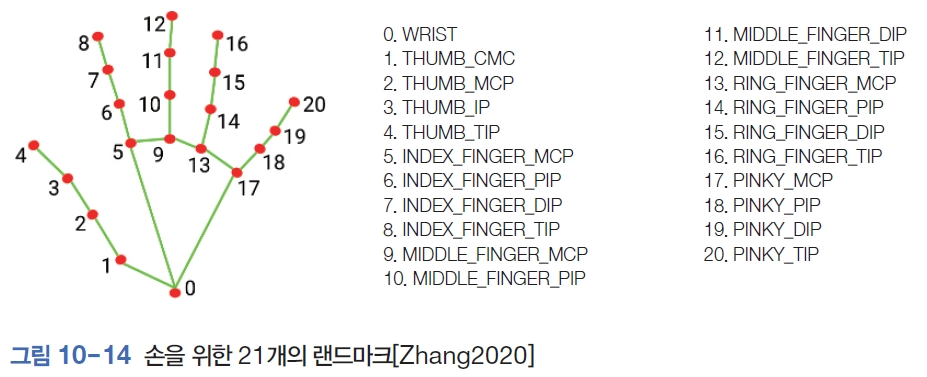

In [14]:
Image("그림 10-14.jpg", width=720)

In [11]:
import cv2
import mediapipe as mp

# 1. 테스트할 유튜브 영상 링크
#stream_link = get_youtube_streamlink("https://youtube.com/shorts/jH_27eHr_Bo?si=rGNbBKPbiqldOpdQ")  
cap = cv2.VideoCapture("hand.mp4")

BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

# 실시간 웹캠 영상을 처리하기 위해 'VIDEO' 모드로 설정
options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path='hand_landmarker.task'),
    running_mode=VisionRunningMode.VIDEO,
    num_hands=2 # 최대 두 손 검출
)

# 그리기 도구 (구식 방식 대신 최신 랜드마크 데이터 구조 표현용)
with HandLandmarker.create_from_options(options) as landmarker:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # OpenCV(BGR) 이미지 -> MediaPipe(RGB) 변환
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        # 웹캠 프레임별 타임스탬프 (밀리초 단위 계산 필요)
        frame_timestamp_ms = int(cap.get(cv2.CAP_PROP_POS_MSEC))

        # 추론 수행
        result = landmarker.detect_for_video(mp_image, frame_timestamp_ms)

        # 결과가 있고 손이 검출되었다면 시각화
        if result.hand_landmarks:
            h, w, _ = frame.shape
            for hand_landmarks in result.hand_landmarks:
                for landmark in hand_landmarks:
                    # 랜드마크는 0.0 ~ 1.0 사이로 정규화되어 있으므로 픽셀 좌표로 변환
                    cx, cy = int(landmark.x * w), int(landmark.y * h)
                    cv2.circle(frame, (cx, cy), 5, (255, 0, 0), -1)

        cv2.imshow('Hand Tracking', frame)
        if cv2.waitKey(30) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

I0000 00:00:1779593897.942823  138079 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1779593897.979586  138097 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 535.309.01), renderer: NVIDIA GeForce RTX 4090/PCIe/SSE2
W0000 00:00:1779593897.999710  138090 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779593898.012867  138085 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## END 